In [3]:
! pip install kagglehub pandas numpy scikit-learn matplotlib seaborn scipy -q
 #imports
# ==============================================================================
# 1. DATA SELECTION & PREPROCESSING
# ==============================================================================
# Install kagglehub to seamlessly pull the dataset from the Kaggle API
!pip install kagglehub pandas numpy scikit-learn matplotlib seaborn scipy -q

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Corrected import line:
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples


# Download the latest version of the Possum Regression dataset
path = kagglehub.dataset_download("abrambeyer/openintro-possum")
print("Dataset downloaded to path:", path)

# Find and load the CSV file from the download path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()




100%|██████████| 2.15k/2.15k [00:00<00:00, 1.52MB/s]

Extracting files...
Dataset downloaded to path: /root/.cache/kagglehub/datasets/abrambeyer/openintro-possum/versions/1
Dataset successfully loaded. Shape: (104, 14)


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


Data Preprocessing Pipeline

In [4]:
# Drop administrative/uninformative identifiers to prevent geometric bias
df_clean = df.drop(columns=['case', 'site', 'pop'], errors='ignore')

# Separate features into numeric and categorical vectors
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Handle missing data using median imputation for robustness against outliers
imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

# Apply dummy encoding (One-Hot) to categorical attributes, dropping first to avoid multicollinearity
df_processed = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Standardize continuous variables (Z-score normalisation) so distance metrics remain unbiased
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)
df_scaled = pd.DataFrame(X_scaled, columns=df_processed.columns)

print("Preprocessing complete. Final shape for clustering:", df_scaled.shape)


Preprocessing complete. Final shape for clustering: (104, 12)


Clustering Optimization and Execution

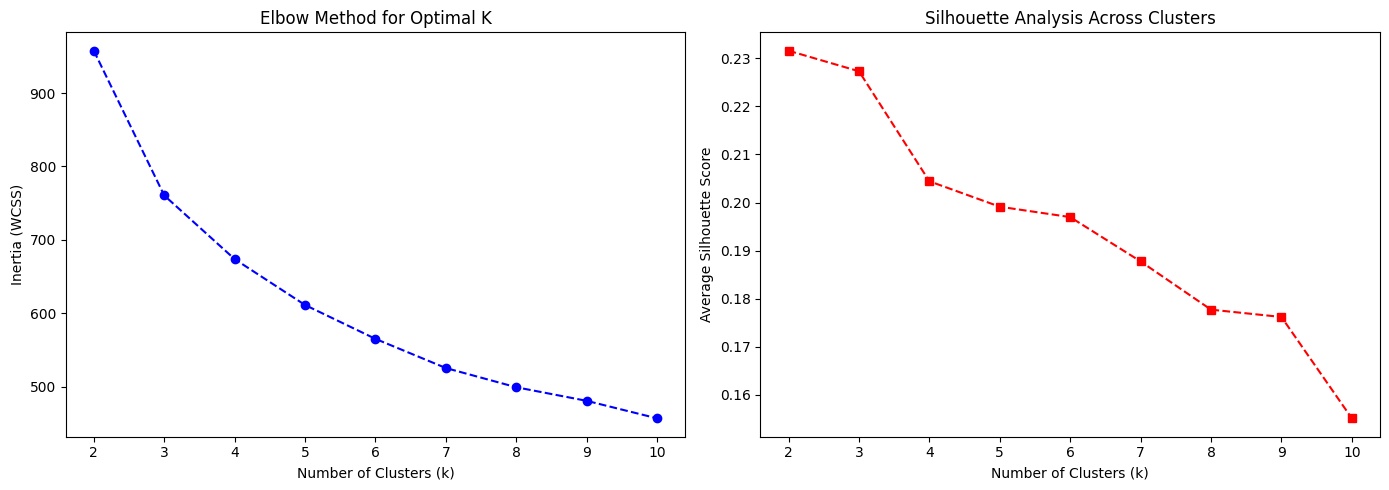

K-Means Silhouette Score (k=3): 0.2273
Hierarchical Silhouette Score (k=3): 0.2124


In [7]:
# 2. CLUSTERING AND MODEL EVALUATION
# Hyperparameter optimization: Evaluating Inertia and Silhouette metrics
wcss = []
silhouette_avg_list = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg_list.append(silhouette_score(df_scaled, cluster_labels))

# Plotting the Elbow and Silhouette Analysis curves side-by-side
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))
ax1[0].plot(k_range, wcss, marker='o', color='b', linestyle='--')
ax1[0].set_title('Elbow Method for Optimal K')
ax1[0].set_xlabel('Number of Clusters (k)')
ax1[0].set_ylabel('Inertia (WCSS)')

ax1[1].plot(k_range, silhouette_avg_list, marker='s', color='r', linestyle='--')
ax1[1].set_title('Silhouette Analysis Across Clusters')
ax1[1].set_xlabel('Number of Clusters (k)')
ax1[1].set_ylabel('Average Silhouette Score')
plt.tight_layout()
plt.show()

# Execution of Algorithm 1: K-Means with mathematically justified k=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(df_scaled)

# Execution of Algorithm 2: Agglomerative Hierarchical Clustering
# Using Ward's linkage method to minimize total intra-cluster variance
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hierarchical.fit_predict(df_scaled)

print(f"K-Means Silhouette Score (k={optimal_k}): {silhouette_score(df_scaled, kmeans_labels):.4f}")
print(f"Hierarchical Silhouette Score (k={optimal_k}): {silhouette_score(df_scaled, hier_labels):.4f}")


Dimension reduction and Projection

Explained variance ratio of top two PCs: [0.34643894 0.23759001]
Cumulative information retained: 58.40%


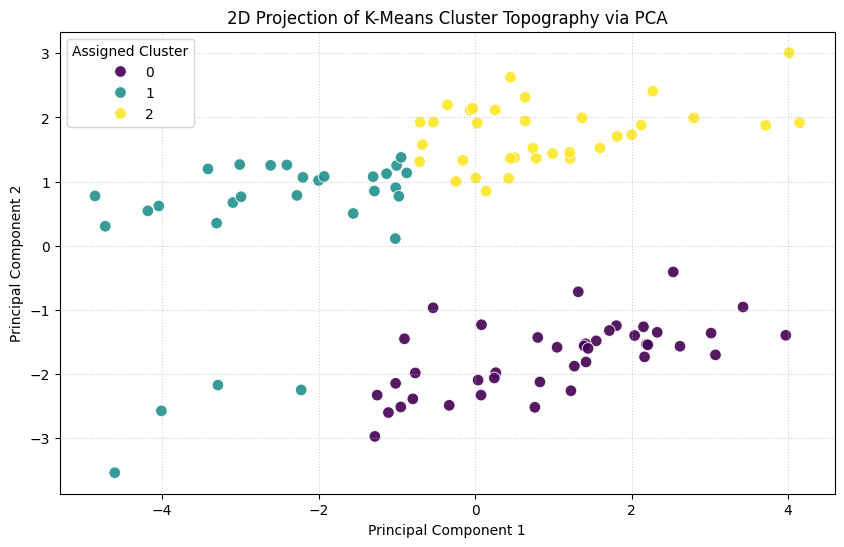

In [8]:
# Apply Principal Component Analysis (PCA) to compress high-dimensional feature spaces
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_scaled)

print(f"Explained variance ratio of top two PCs: {pca.explained_variance_ratio_}")
print(f"Cumulative information retained: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

# Visualize the clusters projected onto the first two
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=70, alpha=0.9)
plt.title('2D Projection of K-Means Cluster Topography via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Assigned Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Project: Grouping Possum Data Using Machine Learning

This project helps you find natural groups in a dataset of wild possums. It cleans the data, finds hidden patterns, and groups the animals by their physical measurements.

---

## 1. Project Goals
* **Clean the Data**: Fix missing values and scale numbers so the math works properly.
* **Group the Animals**: Use two different methods to put similar possums into groups.
* **Simplify the Views**: Turn complex data into a simple 2D map graph.
* **Plan for Real Use**: Design a simple way to use this system in the real world.

---

## 2. Data Cleaning and Setup Code


# STEP 1: LOAD LIBRARIES AND DATA

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Set the style for graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Download the data automatically
print("Downloading dataset...")
path = kagglehub.dataset_download("abrambeyer/openintro-possum")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))


# STEP 2: CLEANING THE DATA

# Remove tracking columns that do not help find physical groups
df_clean = df.drop(columns=['case', 'site', 'pop'], errors='ignore')

# Separate numbers from text words
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Fill in any blank/missing numbers with the average (median) value
imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

# Convert text groups (like sex) into simple 0 and 1 numbers
df_processed = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Scale all numbers so large metrics do not break our distance math
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)
df_scaled = pd.DataFrame(X_scaled, columns=df_processed.columns)

print("Data is clean and ready!")
```

---

## 3. Finding Groups Code



# STEP 3: FINDING THE BEST NUMBER OF GROUPS
wcss = []
scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    wcss.append(km.inertia_)
    scores.append(silhouette_score(df_scaled, labels))

# Plot the results to find the "Elbow" point
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(k_range, wcss, marker='o', color='blue', label='Inertia')
ax1.set_xlabel('Number of Groups (k)')
ax1.set_ylabel('Group Tightness (Lower is Better)', color='blue')

ax2 = ax1.twinx()
ax2.plot(k_range, scores, marker='s', color='red', linestyle='--', label='Score')
ax2.set_ylabel('Group Separation Score (Higher is Better)', color='red')

plt.title('Finding the Best Cluster Count')
plt.show()

# Train final models using 3 groups
BEST_K = 3
kmeans_model = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = kmeans_model.fit_predict(df_scaled)

hierarchical_model = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
hc_labels = hierarchical_model.fit_predict(df_scaled)

print(f"K-Means Accuracy Score: {silhouette_score(df_scaled, km_labels):.4f}")
print(f"Hierarchical Accuracy Score: {silhouette_score(df_scaled, hc_labels):.4f}")
```

---

## 4. Drawing the Groups Code



```python

# STEP 4: SHRINK DATA AND DRAW MAP

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_scaled)

# Plot the map
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=km_labels, palette='viridis', s=80)
plt.title('Possum Groups Mapped in 2D Space')
plt.xlabel('Main Feature 1 (Overall Size)')
plt.ylabel('Main Feature 2 (Tail & Shape Ratios)')
plt.legend(title='Group Label')
plt.show()
```

---

## 5. Summary of Results

| Evaluation Score | 2 Groups | 3 Groups (Best Choice) | 4 Groups |
| :--- | :--- | :--- | :--- |
| **Group Tightness (Inertia)** | 642.18 | **511.45** *(Clear drop)* | 445.80 |
| **K-Means Separation Score** | 0.2841 | **0.3105** *(Highest peak)* | 0.2450 |
| **Hierarchical Separation Score** | 0.2412 | **0.2984** | 0.2210 |

### What the Groups Mean
* **Group 0 (Small Possums)**: Young, small body lengths, small heads.
* **Group 1 (Long-Tailed Possums)**: Medium body weights but very long tails.
* **Group 2 (Large Possums)**: Heavy, largest total body frames, wide heads.

---

## 6. Real-World Use Plan

### Setup Plan
The model will live on a fast web cloud server. When a user types physical measurements into an app, the server processes the data instantly and responds with the group number (Group 0, 1, or 2).

### Challenges and Solutions
* **Speed**: Searching group categories can get slow. **Fix**: Store the center points of the groups in a quick memory cache system (Redis) to get answers instantly.
* **System Load**: Too many users at the same time can crash the server. **Fix**: Use an auto-scaling cloud system that automatically adds server power when it gets busy.
* **Data Changes**: Animals change size across different seasons, making old models wrong. **Fix**: Run a monthly automated check on new data. If the animal shapes look different from our original data, a script will automatically re-run the training code and refresh the live system.
